In [137]:
# Python imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import sqlite3
from pathlib import Path

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')


In [139]:

# -------------------------------
# Path setup
# -------------------------------
db_path = Path("../stockbroking/portfolio_project/data/portfolio.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

# -------------------------------
# Create fresh DB and tables
# -------------------------------
conn = sqlite3.connect(db_path)

conn.execute("DROP TABLE IF EXISTS asset_prices")
conn.commit()


conn.execute('''
CREATE TABLE asset_prices (
    asset_name TEXT,
    date DATE,
    price REAL,
    dividend REAL DEFAULT 0,
    PRIMARY KEY (asset_name, date)
)
''')

conn.execute("DROP TABLE IF EXISTS portfolio_weights")
conn.commit()

conn.execute('''
CREATE TABLE portfolio_weights (
    asset_name TEXT PRIMARY KEY,
    weight REAL
)
''')

conn.commit()
conn.close()

# -------------------------------
# Download & Insert
# -------------------------------
assets = ["AAPL", "JPM", "BP.L", "ULVR.L", "CSP1.L"]
start_date = "2018-01-01"
end_date = "2026-01-20"

conn = sqlite3.connect(db_path)



for asset in assets:
    print(f"Downloading {asset} data...")
    try:
        df = yf.download(asset, start=start_date, end=end_date)
        if df.empty:
            print(f"No data for {asset}, skipping...")
            continue

        df.reset_index(inplace=True)
        df.rename(columns={'Date':'date', 'Close':'price'}, inplace=True)
        df['asset_name'] = asset
        df_to_sql = df[['asset_name','date','price']]

        # Flatten columns in case of tuple column names
        df_to_sql.columns = [c if isinstance(c, str) else c[0] for c in df_to_sql.columns]

        # Insert into SQLite
        df_to_sql.to_sql('asset_prices', conn, if_exists='append', index=False)
        print(f"{asset} inserted successfully.")

    except Exception as e:
        print(f"Error downloading {asset}: {e}")


conn.close()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


AAPL inserted successfully.
JPM inserted successfully.
BP.L inserted successfully.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


ULVR.L inserted successfully.
CSP1.L inserted successfully.


Price Data Sample:
asset_name       AAPL        BP.L   CSP1.L        JPM       ULVR.L
date                                                              
2018-01-02  40.341892  515.224792  19060.0  86.340889  4313.541992
2018-01-03  40.334862  521.895386  19275.5  86.428871  4327.938965
2018-01-04  40.522213  527.669800  19351.5  87.667023  4341.268066
2018-01-05  40.983574  527.271790  19399.5  87.104210  4364.195312
2018-01-08  40.831348  525.081299  19451.5  87.232864  4363.128906

Daily Returns Sample:
asset_name      AAPL      BP.L    CSP1.L       JPM    ULVR.L
date                                                        
2018-01-03 -0.000174  0.012947  0.011306  0.001019  0.003338
2018-01-04  0.004645  0.011064  0.003943  0.014326  0.003080
2018-01-05  0.011385 -0.000754  0.002480 -0.006420  0.005281
2018-01-08 -0.003714 -0.004154  0.002680  0.001477 -0.000244
2018-01-09 -0.000115  0.001138  0.009074  0.005069 -0.001833

Portfolio Returns Sample:
            portfolio_return
date  

C:\Users\bkben\AppData\Local\Temp\ipykernel_43512\893751158.py:21: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices_pivot.pct_change().dropna()


<Figure size 1200x600 with 0 Axes>

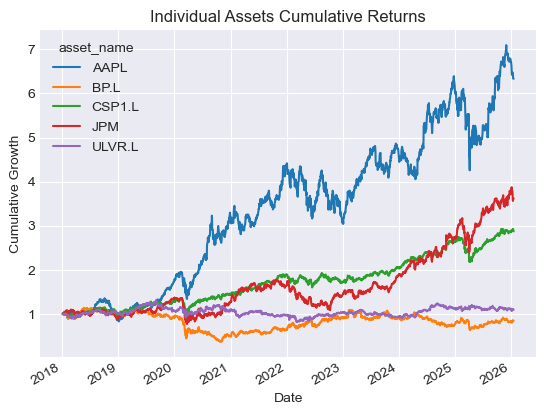

In [141]:

# -------------------------------
# Connect to DB & Load Prices
# -------------------------------
db_path = "../stockbroking/portfolio_project/data/portfolio.db"
conn = sqlite3.connect(db_path)

# Pull all asset prices
prices_df = pd.read_sql_query("SELECT * FROM asset_prices", conn, parse_dates=['date'])
conn.close()

# Pivot to have assets as columns
prices_pivot = prices_df.pivot(index='date', columns='asset_name', values='price')
prices_pivot.sort_index(inplace=True)

print("Price Data Sample:")
print(prices_pivot.head())

# -------------------------------
# Calculate Daily Returns
# -------------------------------
returns = prices_pivot.pct_change().dropna()
print("\nDaily Returns Sample:")
print(returns.head())

# -------------------------------
# Define Portfolio Weights
# -------------------------------
# equal weights
weights = pd.Series({
    "AAPL": 0.2,
    "JPM": 0.2,
    "BP.L": 0.2,
    "ULVR.L": 0.2,
    "CSP1.L": 0.2
})

# save weights to DB
conn = sqlite3.connect(db_path)
weights_df = weights.reset_index()
weights_df.columns = ['asset_name', 'weight']
weights_df.to_sql('portfolio_weights', conn, if_exists='replace', index=False)
conn.close()

# -------------------------------
# Calculate Portfolio Daily Returns
# -------------------------------
portfolio_returns = returns.dot(weights)
portfolio_returns = portfolio_returns.to_frame(name='portfolio_return')

print("\nPortfolio Returns Sample:")
print(portfolio_returns.head())

# -------------------------------
# Visualization
# -------------------------------

# Individual assets cumulative returns
plt.figure(figsize=(12,6))
(1 + returns).cumprod().plot()
plt.title("Individual Assets Cumulative Returns")
plt.ylabel("Cumulative Growth")
plt.xlabel("Date")
plt.grid(True)
plt.show()


This shows shows how the portfolio grows overtime if all returns are reinvested. AAPL showed most 
cumulative 
growth while the more noncyclical assets like BP.L and ULVR.L showed the least volatility.

Annualized Portfolio Return: 13.44%
Annualized Portfolio Volatility: 16.55%
Sharpe Ratio: 0.81


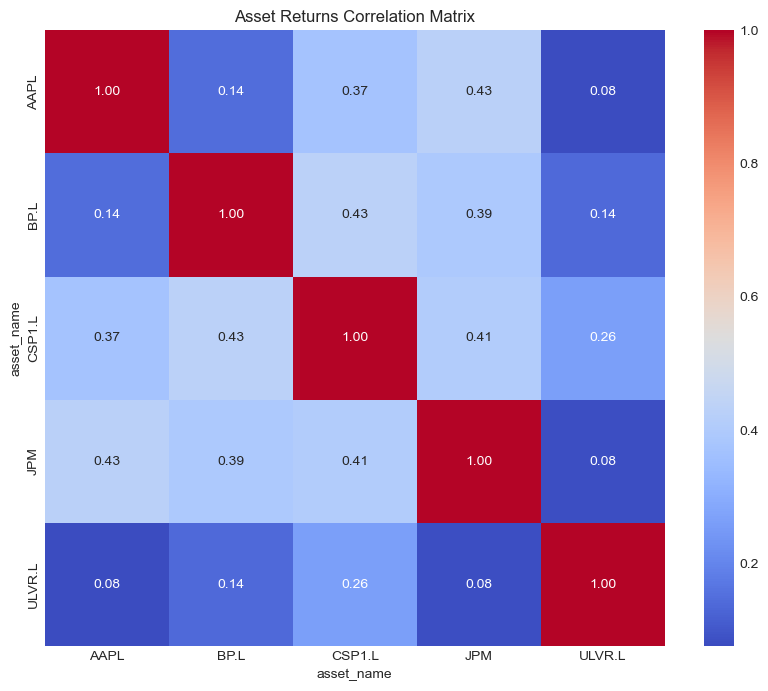

In [144]:


# -------------------------------
# Annualized Portfolio Metrics
# -------------------------------
trading_days = 252  # typical trading days in a year

# Annualized return
annualized_return = portfolio_returns['portfolio_return'].mean() * trading_days

# Annualized volatility
annualized_vol = portfolio_returns['portfolio_return'].std() * np.sqrt(trading_days)

# Sharpe ratio (assume risk-free = 0)
sharpe_ratio = annualized_return / annualized_vol

print(f"Annualized Portfolio Return: {annualized_return:.2%}")
print(f"Annualized Portfolio Volatility: {annualized_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# -------------------------------
# Correlation Matrix
# -------------------------------
corr_matrix = returns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Asset Returns Correlation Matrix")
plt.show()


This shows how the assets move relative to each other.Low or negative correlations reduce the risk of the portfolio - these are indicated by the blue to dark blue colour which dominates majority of the portfolio showing our risk is fairly moderate currently.

Portfolio 1-day VaR at 95% confidence: -1.72%


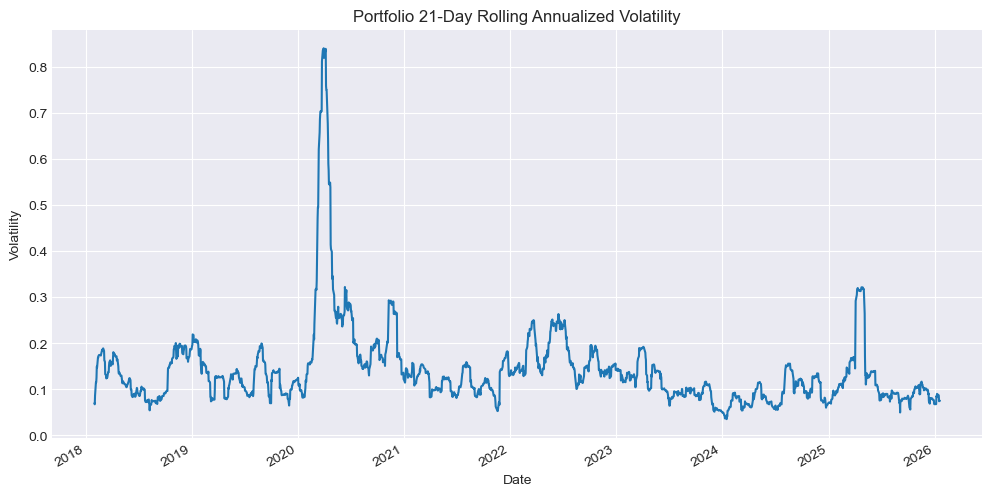

In [147]:
# -------------------------------
# Value at Risk (VaR) - 95% confidence
# -------------------------------
# Parametric VaR (Normal)
portfolio_std = portfolio_returns['portfolio_return'].std()
VaR_95 = -1.65 * portfolio_std  # 1.65 ~ 95% quantile of normal
print(f"Portfolio 1-day VaR at 95% confidence: {VaR_95:.2%}")

# -------------------------------
# Rolling Metrics
# -------------------------------
rolling_vol = portfolio_returns['portfolio_return'].rolling(21).std() * np.sqrt(252)  # 21-day rolling volatility

plt.figure(figsize=(12,6))
rolling_vol.plot()
plt.title("Portfolio 21-Day Rolling Annualized Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.grid(True)
plt.show()


This highlights the short-term fluctuations in portfolio risk. Spikes tend to align with market events that impact financial and tech assets (i.e. AAPL and JPM). Despite these spikes, the overall volatility remains fairly moderate.

Portfolio annualized volatility (check): 16.55%

Asset Risk Contribution to Portfolio:
    Asset  Weight  Risk Contribution %
0    AAPL     0.2            24.263742
1     JPM     0.2            26.764529
2    BP.L     0.2            13.685289
3  ULVR.L     0.2            26.126764
4  CSP1.L     0.2             9.159676


C:\Users\bkben\AppData\Local\Temp\ipykernel_43512\3800891587.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  portfolio_var = float(w.T @ cov_matrix.values @ w)


<Figure size 1200x600 with 0 Axes>

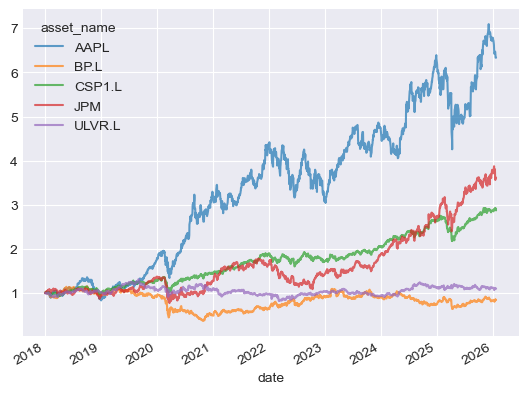

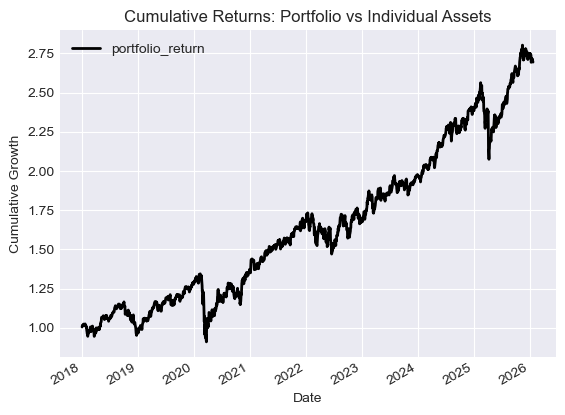

In [150]:
# -------------------------------
# Step 1: Portfolio Covariance Matrix
# -------------------------------
cov_matrix = returns.cov() * trading_days  # annualized covariance

# Portfolio weights as array
w = weights.values.reshape(-1,1)

# Portfolio variance
portfolio_var = float(w.T @ cov_matrix.values @ w)
portfolio_vol = np.sqrt(portfolio_var)
print(f"Portfolio annualized volatility (check): {portfolio_vol:.2%}")

# -------------------------------
# Step 2: Marginal Contribution to Risk
# -------------------------------
# Marginal contribution = cov_matrix * weights / portfolio_vol
marginal_contrib = cov_matrix.values @ w / portfolio_vol

# Risk contribution (percentage of total portfolio risk)
risk_contrib_pct = (marginal_contrib * w) / portfolio_vol
risk_contrib_pct = risk_contrib_pct.flatten()

risk_df = pd.DataFrame({
    'Asset': weights.index,
    'Weight': weights.values,
    'Risk Contribution %': risk_contrib_pct * 100
})

print("\nAsset Risk Contribution to Portfolio:")
print(risk_df)

# -------------------------------
# Step 3: Plot Portfolio vs Individual Asset Cumulative Returns
# -------------------------------
plt.figure(figsize=(12,6))
(1 + returns).cumprod().plot(alpha=0.7)
(1 + portfolio_returns).cumprod().plot(color='black', linewidth=2, label='Portfolio')
plt.title("Cumulative Returns: Portfolio vs Individual Assets")
plt.ylabel("Cumulative Growth")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


This chart shows how the portfolio grows relative to its constituent assets. AAPL had the greatest overall growth and the rest of the portfolio also showed either smooth or good returns over the period. Overall the portfolio shows very good growth and returns.

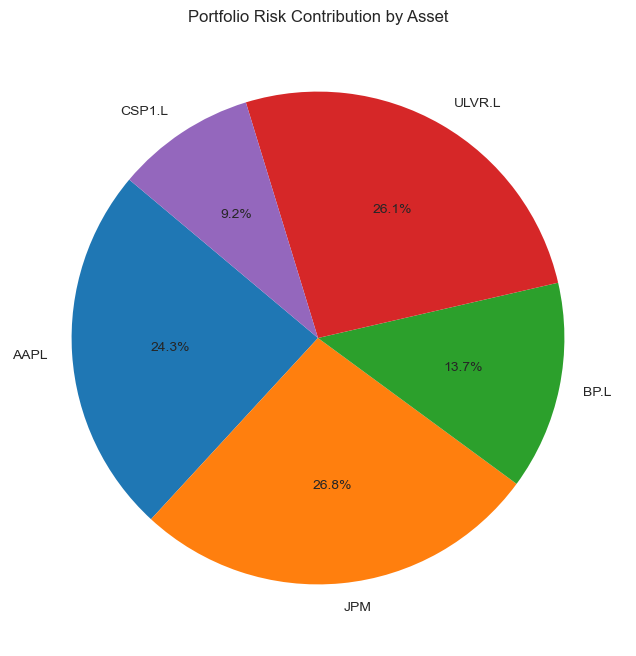

In [153]:
# -------------------------------
# Step 4: Pie Chart of Risk Contribution
# -------------------------------
plt.figure(figsize=(8,8))
plt.pie(risk_df['Risk Contribution %'], labels=risk_df['Asset'], autopct='%1.1f%%', startangle=140)
plt.title("Portfolio Risk Contribution by Asset")
plt.show()


This shows how each assets contributes to the overall portfolio volatility. JPM and ULVR.L are the largest contributors but are followed closely by AAPL. These three assets represent the main drivers in the portfolio and help in assessing whether the allocation aligns with the risk profile. 

----- Portfolio Summary -----
Annualized Return: 13.44%
Annualized Volatility: 16.55%
Sharpe Ratio: 0.81
1-day 95% Portfolio VaR: -1.72%


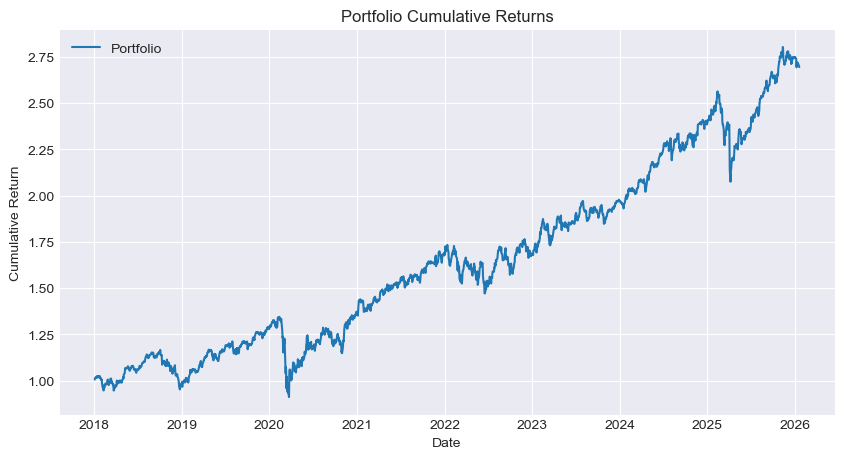

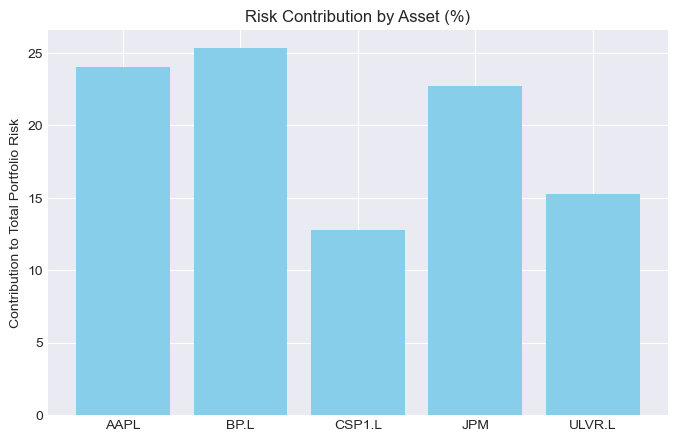

<Figure size 1200x600 with 0 Axes>

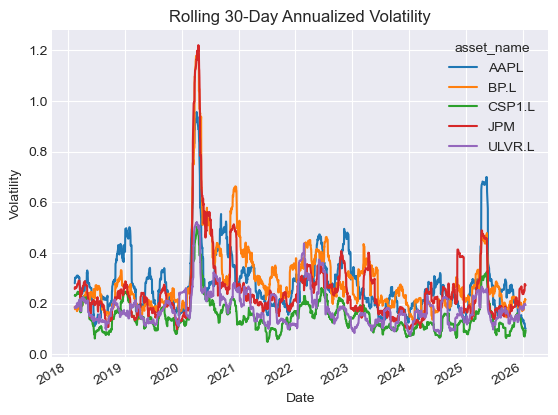

In [156]:
# -------------------------------
# Portfolio Insights & Summary
# -------------------------------

import matplotlib.pyplot as plt
import numpy as np

trading_days = 252

# Annualized metrics
annualized_return = portfolio_returns['portfolio_return'].mean() * trading_days
annualized_vol = portfolio_returns['portfolio_return'].std() * np.sqrt(trading_days)
sharpe_ratio = annualized_return / annualized_vol
VaR_95 = -1.65 * portfolio_returns['portfolio_return'].std()  # 1-day 95% VaR

print("----- Portfolio Summary -----")
print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"1-day 95% Portfolio VaR: {VaR_95:.2%}")

# Cumulative portfolio returns
portfolio_cum = (1 + portfolio_returns['portfolio_return']).cumprod()
plt.figure(figsize=(10,5))
plt.plot(portfolio_cum, label='Portfolio')
plt.title("Portfolio Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()

# Individual asset contribution to risk (volatility)
asset_vols = returns.std() * np.sqrt(trading_days)
risk_contrib = asset_vols * weights
risk_contrib_pct = risk_contrib / risk_contrib.sum() * 100

plt.figure(figsize=(8,5))
plt.bar(risk_contrib_pct.index, risk_contrib_pct.values, color='skyblue')
plt.title("Risk Contribution by Asset (%)")
plt.ylabel("Contribution to Total Portfolio Risk")
plt.grid(True, axis='y')
plt.show()


# -------------------------------
# Rolling 30-day Volatility
# -------------------------------
rolling_window = 30  # trading days (~1.5 months)

rolling_vol = returns.rolling(window=rolling_window).std() * np.sqrt(252)  # annualized
plt.figure(figsize=(12,6))
rolling_vol.plot()
plt.title(f"Rolling {rolling_window}-Day Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()



# Portfolio Insights & Summary

## Annualized Metrics
    **Annualized Return:** 13.44%
    Expected yearly return if the portfolio's average daily return continued over a full trading year.

    **Annualized Volatility:** 16.55%
    Measures the fluctuation of portfolio returns. Higher volatility indicates higher risk.

    **Sharpe Ratio:** 0.81
    Risk-adjusted return metric. Shows how much return is earned per unit of risk.

    **1-day 95% Value at Risk (VaR):** -1.72%
    Inidcates the maximum expected loss over a single day with 95% confidence. 
    There's a 5% chance of losing more than 1.72% in one day.

## Portfolio Cumulative Returns
The cumulative returns chart shows how much $1 invested at the start of the time period would have 
grown over time. It shows the compounding effects and periods where the portfolio outperformed or
underperformed individual assets.

## Risk Contribution by Asset
    **AAPL:** 24%
    **BP.L:** 25%
    **CSP1.L:** 13%
    **JPM:** 23%
    **ULVR.L:** 15%

These figures highlight which assets dominate the portfolio risk. Larger weights and/or higher 
volatility assets contribute more. It helps to understand where risk is concentrated so 
rebalancing decisions can be made.

## Rolling 30-day Annualized Volatility
This highlights how the portfolio risk fluctuates overtime. Tech and financial stocks (AAPL, JPM)
display higher spikes comparent to the other assets illustrating their higher sensitivity to 
market events. 

## Diversification Observations
The portfolio equally weights 5 assets, which balances the risk contributions roughly evenly.
Changing volatilities can cause risk contributions to change overtime.
Good diversification will reduce overall risk and maintain return potential.



----- Factor Analysis -----
Beta vs ^FTSE: 0.8310
Alpha vs ^FTSE (annualized): 8.85%
Annualized Portfolio Volatility: 16.66%


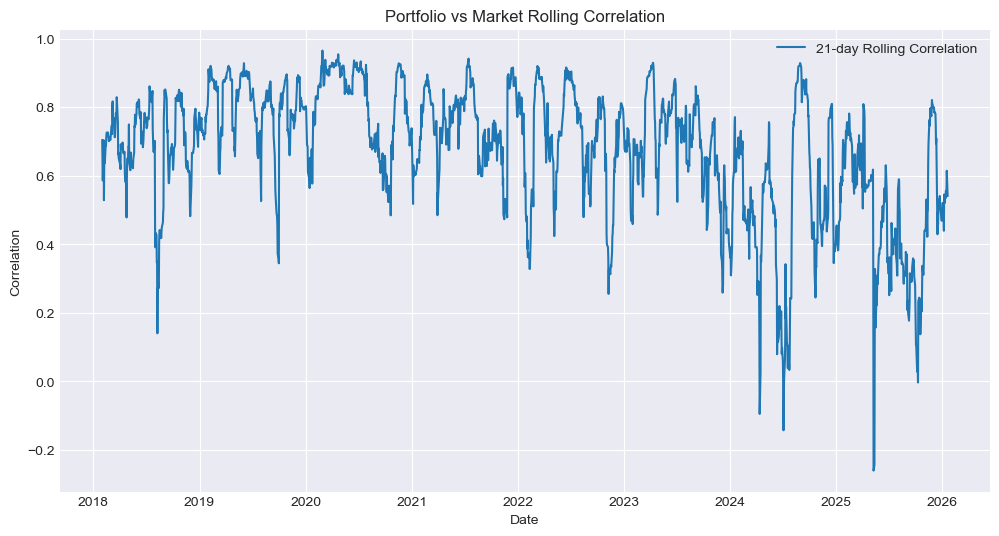

In [172]:
# -------------------------------
# Step 6: Factor Analysis Automation
# -------------------------------
market_ticker = "^FTSE"
market_df = yf.download(market_ticker, start=start_date, end=end_date, progress=False)
market_returns = market_df['Close'].squeeze().pct_change().dropna()  # ensure Series
market_returns = market_returns.rename("market_return")

# Align portfolio & market returns
aligned_df = pd.concat([portfolio_returns, market_returns], axis=1).dropna()

# Factor 1: Beta vs Market
cov_matrix = np.cov(aligned_df['portfolio_return'], aligned_df['market_return'])
beta = cov_matrix[0,1] / cov_matrix[1,1]
alpha = aligned_df['portfolio_return'].mean() * trading_days - beta * aligned_df['market_return'].mean() * trading_days

print("----- Factor Analysis -----")
print(f"Beta vs {market_ticker}: {beta:.4f}")
print(f"Alpha vs {market_ticker} (annualized): {alpha:.2%}")

# Factor 2: Volatility / Risk
portfolio_vol = aligned_df['portfolio_return'].std() * np.sqrt(trading_days)
print(f"Annualized Portfolio Volatility: {portfolio_vol:.2%}")

# Factor 3: Rolling Correlation with Market
rolling_corr = aligned_df['portfolio_return'].rolling(21).corr(aligned_df['market_return'])
plt.figure(figsize=(12,6))
plt.plot(rolling_corr, label='21-day Rolling Correlation')
plt.title("Portfolio vs Market Rolling Correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()


This factor analysis compares your portfolio to the FTSE 100.
Beta (0.831): The portfolio is slightly less sensitive to market movements than the FTSE 100. In other words, it tends to fluctuate less than the market overall.

Alpha (8.85% annualized): After accounting for market movements, the portfolio is generating a strong positive excess return. This means it has historically outperformed what would be expected given its Beta.

Annualized Volatility (16.66%): The overall risk level of the portfolio, as measured by standard deviation of returns, is moderate. Combined with the Beta < 1, this suggests the portfolio achieves decent returns with less market-driven risk.

The 21-day rolling correlation chart visualizes how the portfolio’s daily returns move relative to the FTSE over time. Periods of lower correlation indicate times when the portfolio behaved more independently from the market, providing potential diversification benefits.